In [13]:
import loompy as lp
import pandas as pd
from pyscenic.binarization import binarize

from pyscenic.rss import regulon_specificity_scores
from pyscenic.plotting import plot_rss
import matplotlib.pyplot as plt
from adjustText import adjust_text
import seaborn as sns
import numpy as np


## STEP 0. Preprocessing in seurat5_R4.4.1

In [ ]:
library(Matrix)
library(Seurat)

### 1. rds to matrix

In [ ]:
scdata=readRDS("/syn2/zhaolian/3.JiLab/results/2.scRNAseq/4.integrated_byTypeReClustering/step5.integrate_splitByMouse_nod_rmImmuneEndothelial_splitByMouse_harmony_1_20_0.2.rds")
setwd("/syn2/zhaolian/3.JiLab/results/2.scRNAseq/4.integrated_byTypeReClustering/matrix_step5")
seurat_object <- scdata
######################################################################
# 提取稀疏 counts 矩阵
counts <- GetAssayData(seurat_object, assay = "RNA", layer = "counts")
# 保存为 Matrix Market 格式（稀疏矩阵）
writeMM(counts, file = "matrix.mtx")
# 保存基因名（行为 feature）
write.table(rownames(counts), file = "features.tsv", sep = "\t", quote = FALSE, row.names = FALSE, col.names = FALSE)
# 保存细胞名（列为 barcodes）
write.table(colnames(counts), file = "barcodes.tsv", sep = "\t", quote = FALSE, row.names = FALSE, col.names = FALSE)
######################################################################
meta <- seurat_object@meta.data
umap <- Embeddings(seurat_object, reduction = "umap.harmony")
write.csv(meta, file = "metadata.csv")
write.csv(umap, file = "umap.csv")

### 2. rds to matrix, metacell

In [10]:
scdata=readRDS("/syn2/zhaolian/3.JiLab/results/2.scRNAseq/4.integrated_byTypeReClustering/NOD_Metacell_from_hdWGCNA.rds")
setwd("/syn2/zhaolian/3.JiLab/results/2.scRNAseq/4.integrated_byTypeReClustering/matrix_metacell/")
seurat_object <- scdata
######################################################################
# 提取稀疏 counts 矩阵
counts <- GetAssayData(seurat_object, assay = "SCT", layer = "counts")
# 保存为 Matrix Market 格式（稀疏矩阵）
writeMM(counts, file = "matrix.mtx")
# 保存基因名（行为 feature）
write.table(rownames(counts), file = "features.tsv", sep = "\t", quote = FALSE, row.names = FALSE, col.names = FALSE)
# 保存细胞名（列为 barcodes）
write.table(colnames(counts), file = "barcodes.tsv", sep = "\t", quote = FALSE, row.names = FALSE, col.names = FALSE)
######################################################################
meta <- seurat_object@meta.data
umap <- Embeddings(seurat_object, reduction = "umap")
write.csv(meta, file = "metadata.csv")
write.csv(umap, file = "umap.csv")

NULL

An object of class Seurat 
30047 features across 5730 samples within 1 assay 
Active assay: SCT (30047 features, 0 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

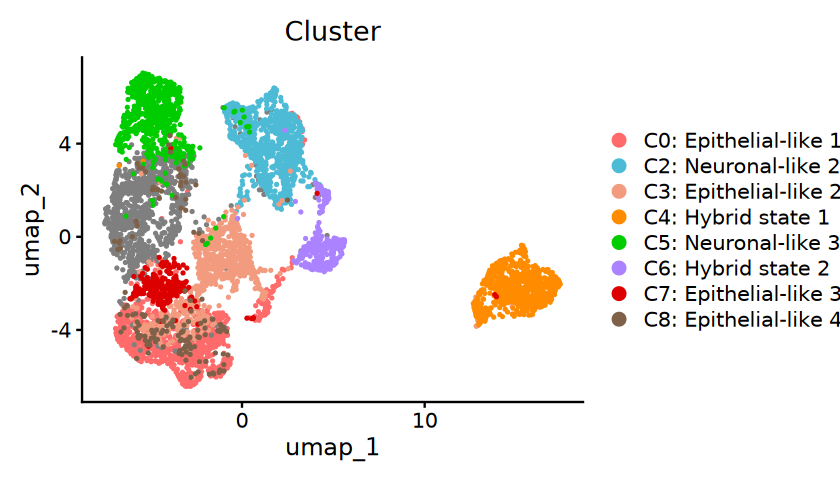

In [17]:
scdata
options(repr.plot.width =7, repr.plot.height =4)
mycols=c('C0: Epithelial-like 1'="#FF6A6A",'C0: Epithelial-like 1'="#00A087FF",'C2: Neuronal-like 2'="#4DBBD5FF",'C3: Epithelial-like 2'="#F39B7FFF",
         'C4: Hybrid state 1'="#FF8C00",'C5: Neuronal-like 3'="#00CD00",'C6: Hybrid state 2'="#AB82FF",'C7: Epithelial-like 3'="#DC0000FF",'C8: Epithelial-like 4'="#7E6148FF")
DimPlot(scdata,reduction = "umap",ncol=1,
  group.by = c("Cluster"),raster=FALSE,label = FALSE,cols=mycols)

## STEP 0. Preprocessing in pyscenic_python3.10

### 1. matrix to h5ad

In [3]:
import pandas as pd
import os
from scipy.io import mmread
import anndata as ad

INDIR="/syn2/zhaolian/3.JiLab/results/2.scRNAseq/4.integrated_byTypeReClustering/matrix_step5/"
# INDIR="/syn2/zhaolian/3.JiLab/results/2.scRNAseq/4.integrated_byTypeReClustering/matrix_metacell/"
os.chdir(INDIR)

In [4]:
# === 1. 加载表达矩阵 ===
X = mmread("matrix.mtx").T.tocsr()
# === 2. 加载行名（基因）和列名（细胞） ===
var_names = pd.read_csv("features.tsv", header=None, sep="\t")[0].values
obs_names = pd.read_csv("barcodes.tsv", header=None, sep="\t")[0].values
# === 3. 构建基础 AnnData ===
adata = ad.AnnData(X=X)
adata.var_names = var_names
adata.obs_names = obs_names
# === 4. 加载 metadata.csv（细胞注释）并合并 ===
meta = pd.read_csv("metadata.csv", index_col=0)
# 确保索引匹配
meta = meta.loc[adata.obs_names]
adata.obs = meta
# === 5. 加载 umap.csv（坐标）并存入 obsm ===
umap = pd.read_csv("umap.csv", index_col=0)
# 确保索引匹配
umap = umap.loc[adata.obs_names]
adata.obsm["X_umap"] = umap.values  # 必须是 numpy array

# ✅ 检查
print(adata)
print(adata.obs.head())
print(adata.obsm["X_umap"][:5])
# 保存为 .h5ad
adata.write("/syn2/zhaolian/3.JiLab/results/2.scRNAseq/4.integrated_byTypeReClustering/step5.scdata_harmony_1_20_0.2.h5ad")

AnnData object with n_obs × n_vars = 5730 × 30047
    obs: 'orig.ident', 'nCount_SCT', 'nFeature_SCT', 'cells_merged', 'Cluster'
    obsm: 'X_umap'
                                    orig.ident  nCount_SCT  nFeature_SCT  \
C0: Epithelial-like 1_1  C0: Epithelial-like 1    12321.32         13880   
C0: Epithelial-like 1_2  C0: Epithelial-like 1    12346.24         14456   
C0: Epithelial-like 1_3  C0: Epithelial-like 1    12641.20         14775   
C0: Epithelial-like 1_4  C0: Epithelial-like 1    12705.60         13488   
C0: Epithelial-like 1_5  C0: Epithelial-like 1    12596.10         14226   

                                                              cells_merged  \
C0: Epithelial-like 1_1  C4011_LLT-1_AAGACAATCTCCGAAA-1,C4011_LLT-1_GTG...   
C0: Epithelial-like 1_2  C4033_ThyT_TGATGCAAGTCCTACA-1,C4033_Spt_GCTGCA...   
C0: Epithelial-like 1_3  C4007_LLT-1_ACTGTGATCATGACAC-1,C4007_LLT-1_CGG...   
C0: Epithelial-like 1_4  C4007_ThyT_GAGTGAGGTCGATTCA-1,C4007_ThyT_ACGCA...   
C0: E

### 2. h5ad to loom

In [ ]:
import scanpy as sc
import pandas as pd
import random
import numpy as np
import loompy as lp
import anndata as ad

In [ ]:
mapping = {
    0: 'Epithelial-like', 3: 'Epithelial-like',
    7: 'Epithelial-like', 8: 'Epithelial-like',
    1: 'Neuronal-like',   2: 'Neuronal-like',
    5: 'Neuronal-like'
}
adata.obs['cell_state'] = adata.obs['harmony_cluster'].map(mapping).fillna('Hybrid-state')

adata.obs['harmony_cluster'].value_counts()
adata.obs['cell_state'].value_counts()
adata.write("/syn2/zhaolian/3.JiLab/results/2.scRNAseq/4.integrated_byTypeReClustering/step5.scdata_harmony_1_20_0.2.h5ad")

In [ ]:
row_attrs = {
"Gene": np.array(adata.var_names),
}

col_attrs = {
"CellID": np.array(adata.obs_names),
"nGene": np.array(np.sum(adata.X.transpose()>0, axis=0)).flatten(),
"nUMI": np.array(np.sum(adata.X.transpose(),axis=0)).flatten(),
"cluster": np.array(adata.obs.harmony_cluster),
}
lp.create("/syn2/zhaolian/3.JiLab/results/2.scRNAseq/4.integrated_byTypeReClustering/step5.scdata_harmony_1_20_0.2.loom",adata.X.transpose(),row_attrs,col_attrs)

### 3. h5ad to loom, downsampling 2000 cells per cluster

In [ ]:
max_cells_per_cluster = 2000

adata.obs['harmony_cluster'] = 'C' + adata.obs['harmony_cluster'].astype(str)
# 获取各个 cluster 的 index
sampled_indices = (
    adata.obs
    .groupby('harmony_cluster')
    .apply(lambda x: x.sample(n=min(len(x), max_cells_per_cluster), random_state=0))
    .index.get_level_values(1)
)

# 子集化 AnnData 对象
adata_downsampled = adata[sampled_indices].copy()
############################
row_attrs = {
"Gene": np.array(adata_downsampled.var_names),
}

col_attrs = {
"CellID": np.array(adata_downsampled.obs_names),
"nGene": np.array(np.sum(adata_downsampled.X.transpose()>0, axis=0)).flatten(),
"nUMI": np.array(np.sum(adata_downsampled.X.transpose(),axis=0)).flatten(),
"cluster": np.array(adata_downsampled.obs.harmony_cluster),
}
lp.create("/syn2/zhaolian/3.JiLab/results/2.scRNAseq/6.2.GRN/step5.scdata_harmony_1_20_0.2_down2000.loom",
          adata_downsampled.X.transpose(),row_attrs,col_attrs)

### 4. metacell

In [2]:
import pandas as pd
import os
from scipy.io import mmread
import anndata as ad

INDIR="/syn2/zhaolian/3.JiLab/results/2.scRNAseq/4.integrated_byTypeReClustering/matrix_metacell/"
os.chdir(INDIR)

# === 1. 加载表达矩阵 ===
X = mmread("matrix.mtx").T.tocsr()
# === 2. 加载行名（基因）和列名（细胞） ===
var_names = pd.read_csv("features.tsv", header=None, sep="\t")[0].values
obs_names = pd.read_csv("barcodes.tsv", header=None, sep="\t")[0].values
# === 3. 构建基础 AnnData ===
adata = ad.AnnData(X=X)
adata.var_names = var_names
adata.obs_names = obs_names
# === 4. 加载 metadata.csv（细胞注释）并合并 ===
meta = pd.read_csv("metadata.csv", index_col=0)
# 确保索引匹配
meta = meta.loc[adata.obs_names]
adata.obs = meta
# === 5. 加载 umap.csv（坐标）并存入 obsm ===
umap = pd.read_csv("umap.csv", index_col=0)
# 确保索引匹配
umap = umap.loc[adata.obs_names]
adata.obsm["X_umap"] = umap.values  # 必须是 numpy array

# ✅ 检查
print(adata)
print(adata.obs.head())
print(adata.obsm["X_umap"][:5])
# 保存为 .h5ad
adata.write(INDIR+"metacell.h5ad")


AnnData object with n_obs × n_vars = 5730 × 30047
    obs: 'orig.ident', 'nCount_SCT', 'nFeature_SCT', 'cells_merged', 'Cluster'
    obsm: 'X_umap'
                                    orig.ident  nCount_SCT  nFeature_SCT  \
C0: Epithelial-like 1_1  C0: Epithelial-like 1    12321.32         13880   
C0: Epithelial-like 1_2  C0: Epithelial-like 1    12346.24         14456   
C0: Epithelial-like 1_3  C0: Epithelial-like 1    12641.20         14775   
C0: Epithelial-like 1_4  C0: Epithelial-like 1    12705.60         13488   
C0: Epithelial-like 1_5  C0: Epithelial-like 1    12596.10         14226   

                                                              cells_merged  \
C0: Epithelial-like 1_1  C4011_LLT-1_AAGACAATCTCCGAAA-1,C4011_LLT-1_GTG...   
C0: Epithelial-like 1_2  C4033_ThyT_TGATGCAAGTCCTACA-1,C4033_Spt_GCTGCA...   
C0: Epithelial-like 1_3  C4007_LLT-1_ACTGTGATCATGACAC-1,C4007_LLT-1_CGG...   
C0: Epithelial-like 1_4  C4007_ThyT_GAGTGAGGTCGATTCA-1,C4007_ThyT_ACGCA...   
C0: E

In [3]:
import scanpy as sc
import pandas as pd
import random
import numpy as np
import loompy as lp
import anndata as ad

In [4]:
adata.obs['Cluster'].value_counts()

Cluster
C0: Epithelial-like 1    1000
C1: Neuronal-like 1      1000
C2: Neuronal-like 2       873
C3: Epithelial-like 2     778
C4: Hybrid state 1        742
C5: Neuronal-like 3       633
C6: Hybrid state 2        313
C7: Epithelial-like 3     240
C8: Epithelial-like 4     151
Name: count, dtype: int64

In [7]:
row_attrs = {
"Gene": np.array(adata.var_names),
}

col_attrs = {
"CellID": np.array(adata.obs_names),
"nGene": np.array(np.sum(adata.X.transpose()>0, axis=0)).flatten(),
"nUMI": np.array(np.sum(adata.X.transpose(),axis=0)).flatten(),
"cluster": np.array(adata.obs.Cluster),
}
lp.create(INDIR+"metacell.loom",adata.X.transpose(),row_attrs,col_attrs)

## STEP 1: Network inference based on GRNBoost2 from CLI

In [ ]:
!/home/liangzhen/anaconda3/envs/pyscenic/bin/pyscenic grn \
    --num_workers 10 \
    --output adj.tsv \
    --method grnboost2 /syn2/zhaolian/3.JiLab/results/2.scRNAseq/4.integrated_byTypeReClustering/matrix_metacell/metacell.loom ../database/mm_mgi_tfs.txt

## STEP 2-3: Regulon prediction aka cisTarget from CLI

In [ ]:
!/home/liangzhen/anaconda3/envs/pyscenic/bin/pyscenic ctx adj.tsv ../database/mm10_10kbp_up_10kbp_down_full_tx_v10_clust.genes_vs_motifs.rankings.feather \
    --annotations_fname ../database/motifs-v10nr_clust-nr.mgi-m0.001-o0.0.tbl \
    --expression_mtx_fname /syn2/zhaolian/3.JiLab/results/2.scRNAseq/4.integrated_byTypeReClustering/matrix_metacell/metacell.loom \
    --mode "dask_multiprocessing" \
    --output reg.csv \
    --num_workers 10 \
    --mask_dropouts

In [44]:
import pandas as pd

INDIR="/syn2/zhaolian/3.JiLab/results/2.scRNAseq/6.2.GRN/cluster_down_all/"
# 读取regulon文件
regulon_df = pd.read_csv(INDIR+"reg.csv")
# 显示所有列（reg.csv 中通常包含：regulon名称、target基因、motif等信息）
print(regulon_df.columns)

Index(['Unnamed: 0', 'Unnamed: 1', 'Enrichment', 'Enrichment.1',
       'Enrichment.2', 'Enrichment.3', 'Enrichment.4', 'Enrichment.5',
       'Enrichment.6', 'Enrichment.7'],
      dtype='object')


In [ ]:
# # REGULONS_DAT_FNAME = os.path.join(RESULTS_FOLDERNAME, '{}.regulons.dat'.format(DATASET_ID))
# # MOTIFS_FNAME = os.path.join(RESULTS_FOLDERNAME, '{}.motifs.csv'.format(DATASET_ID))
# MOTIFS_FNAME=INDIR+"reg.csv"
# REGULONS_DAT_FNAME = INDIR+'regulons.dat'

# df_motifs = load_motifs(MOTIFS_FNAME)
# regulons = derive_regulons(df_motifs)
# # Pickle these regulons.
# with open(REGULONS_DAT_FNAME, 'wb') as f:
#     pickle.dump(regulons, f)

## STEP 4: Cellular enrichment aka AUCell

In [ ]:
!/home/liangzhen/anaconda3/envs/pyscenic/bin/pyscenic aucell /syn2/zhaolian/3.JiLab/results/2.scRNAseq/4.integrated_byTypeReClustering/matrix_metacell/metacell.loom reg.csv \
    --output adatas_SCENIC.loom \
    --num_workers 10

## STEP 5: plot RSS

In [46]:
INDIR="/syn2/zhaolian/3.JiLab/results/2.scRNAseq/6.2.GRN/cluster_down_all/"
lf = lp.connect(INDIR+"adatas_SCENIC.loom", mode='r+', validate=False)
auc_mtx = pd.DataFrame(lf.ca.RegulonsAUC, index=lf.ca.CellID)
exprMat = pd.DataFrame( lf[:,:], index=lf.ra.Gene, columns=lf.ca.CellID).T
# 建 DataFrame
reg_df = pd.DataFrame(lf.ra.Regulons, index=lf.ra.Gene)
reg_df.to_csv(INDIR+'result0.reg_df.csv')
# 遍历每一列（调控子）
regulons = {}
for i, r in reg_df.items():          # ← 改用 .items()
    regulons[i] = r[r == 1].index.tolist()
    
cellAnnot = pd.concat(
    [
        pd.DataFrame( lf.ca.CellID, index=lf.ca.CellID ),
        pd.DataFrame( lf.ca.cluster, index=lf.ca.CellID ),
        pd.DataFrame( lf.ca.nGene, index=lf.ca.CellID ),
        pd.DataFrame( lf.ca.nUMI, index=lf.ca.CellID ),
    ],
    axis=1
)
cellAnnot.columns = [
 'Celltype',
 'ClusterID',
 'nGene',
 'nUMI'
]
lf.close()

In [82]:
exprMat

,Gm26206,Xkr4,Gm18956,LOC118567655,Gm7341,LOC108167595,Gm27396,Rp1,Gm6101,Sox17,...,TrnL2,ND5,ND6,TrnE,CYTB,TrnT,TrnP,SMALT-Target,AI-Target,puroR-Target
C4007_LLT-1_CCGTGAGCAGAGCTAG-1,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,13,0,0,3,2,0
C4011_LLT-2_ACGGGTCAGATGAACT-1,0,0,0,0,0,0,0,0,0,0,...,0,9,0,0,54,0,0,0,2,1
C4011_ThyT_AGATCCACAGTTCCAA-1,0,0,0,0,0,0,0,0,0,0,...,0,12,0,0,33,0,0,0,0,0
C4007_LLT-2_TACGCTCCACAATGTC-1,0,0,0,0,0,0,0,0,0,0,...,0,3,1,0,67,0,0,0,329,2
C4033_LLT-2_CAACGGCGTACAGAAT-1,0,0,0,0,0,0,0,0,0,0,...,0,3,1,0,29,0,0,0,54,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
C4011_LLT-1_TGTTGAGCATGGAAGC-1,0,5,0,0,0,0,0,0,0,0,...,0,17,1,0,70,0,0,1,2,0
C4033_LLT-1_TCATTTGGTCCTACAA-1,0,1,0,1,0,0,0,0,0,0,...,0,6,2,0,40,0,0,0,40,0
C4033_ThyT_CAACAGTAGAGGTTAT-1,0,0,0,0,0,0,0,0,0,0,...,0,3,0,0,19,0,0,0,135,1
C4033_LLT-1_TGAGTCACAGTTAGGG-1,0,3,0,0,0,0,0,0,0,0,...,0,7,1,0,56,0,0,0,97,2


In [93]:
col_sums[col_sums<=2]

Gm26206         0
Gm18956         0
Gm7341          0
LOC108167595    0
Gm27396         0
               ..
LOC673652       0
LOC434608       0
LOC118568476    0
LOC100861738    0
TrnK            0
Length: 22554, dtype: int64

In [53]:
import pandas as pd

# regulons
rows = []
for key, genes in regulons.items():
    for gene in genes:
        rows.append({'Category': key, 'Gene': gene})

df = pd.DataFrame(rows)

# 保存为 CSV
df.to_csv(INDIR+'regulons.csv', index=False, encoding='utf-8')

In [33]:
cellAnnot

,Celltype,ClusterID,nGene,nUMI
C4007_LLT-1_CCGTGAGCAGAGCTAG-1,C4007_LLT-1_CCGTGAGCAGAGCTAG-1,C0,2208,6251
C4011_LLT-2_ACGGGTCAGATGAACT-1,C4011_LLT-2_ACGGGTCAGATGAACT-1,C0,2609,9017
C4011_ThyT_AGATCCACAGTTCCAA-1,C4011_ThyT_AGATCCACAGTTCCAA-1,C0,2353,7236
C4007_LLT-2_TACGCTCCACAATGTC-1,C4007_LLT-2_TACGCTCCACAATGTC-1,C0,7001,27923
C4033_LLT-2_CAACGGCGTACAGAAT-1,C4033_LLT-2_CAACGGCGTACAGAAT-1,C0,2592,6724
...,...,...,...,...
C4011_LLT-1_TGTTGAGCATGGAAGC-1,C4011_LLT-1_TGTTGAGCATGGAAGC-1,C8,5756,21812
C4033_LLT-1_TCATTTGGTCCTACAA-1,C4033_LLT-1_TCATTTGGTCCTACAA-1,C8,4817,14480
C4033_ThyT_CAACAGTAGAGGTTAT-1,C4033_ThyT_CAACAGTAGAGGTTAT-1,C8,3581,10084
C4033_LLT-1_TGAGTCACAGTTAGGG-1,C4033_LLT-1_TGAGTCACAGTTAGGG-1,C8,3878,9399


In [34]:
auc_mtx

,Ar(+),Atf3(+),Atf4(+),Bclaf1(+),Bptf(+),Cebpd(+),Chd1(+),Clock(+),Ctcf(+),E2f2(+),...,Xbp1(+),Ybx1(+),Yy1(+),Zbtb20(+),Zeb1(+),Zfp148(+),Zfp367(+),Zfp467(+),Zfp551(+),Zfp704(+)
C4007_LLT-1_CCGTGAGCAGAGCTAG-1,0.033591,0.104046,0.145321,0.081512,0.089622,0.000000,0.077759,0.059576,0.157781,0.000000,...,0.110586,0.173545,0.111117,0.065884,0.013556,0.081182,0.070289,0.000876,0.048897,0.074224
C4011_LLT-2_ACGGGTCAGATGAACT-1,0.039642,0.063570,0.126561,0.083359,0.071174,0.000000,0.074210,0.045647,0.226438,0.112935,...,0.053061,0.197462,0.110154,0.064075,0.003225,0.059566,0.134332,0.000000,0.055248,0.067558
C4011_ThyT_AGATCCACAGTTCCAA-1,0.037290,0.069540,0.108148,0.078885,0.055840,0.000000,0.067523,0.042098,0.070067,0.045194,...,0.088948,0.189894,0.099354,0.055778,0.009965,0.061074,0.105644,0.013280,0.001714,0.060260
C4007_LLT-2_TACGCTCCACAATGTC-1,0.027850,0.076131,0.107577,0.144759,0.119189,0.000000,0.171412,0.185769,0.239646,0.114419,...,0.083051,0.122101,0.159420,0.173890,0.128530,0.174184,0.213839,0.000000,0.000000,0.203110
C4033_LLT-2_CAACGGCGTACAGAAT-1,0.000000,0.123881,0.116795,0.110181,0.094928,0.034365,0.122404,0.108060,0.106546,0.000000,...,0.125803,0.147795,0.127134,0.098983,0.040394,0.117408,0.069107,0.000000,0.025251,0.123424
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
C4011_LLT-1_TGTTGAGCATGGAAGC-1,0.000000,0.081079,0.110202,0.102052,0.090111,0.000000,0.105494,0.085794,0.139636,0.000000,...,0.081013,0.173891,0.123889,0.089168,0.000000,0.101338,0.088153,0.000000,0.024965,0.114039
C4033_LLT-1_TCATTTGGTCCTACAA-1,0.054065,0.103506,0.133601,0.108894,0.089008,0.000000,0.117904,0.082863,0.372575,0.000000,...,0.042621,0.171550,0.129037,0.101627,0.047438,0.098654,0.193122,0.048740,0.023800,0.104780
C4033_ThyT_CAACAGTAGAGGTTAT-1,0.014486,0.104421,0.134919,0.099260,0.081228,0.053501,0.100626,0.086945,0.117931,0.000000,...,0.081780,0.174200,0.121136,0.097522,0.029622,0.111182,0.079335,0.020485,0.000923,0.116384
C4033_LLT-1_TGAGTCACAGTTAGGG-1,0.022686,0.113234,0.102146,0.131324,0.115965,0.000000,0.154564,0.134179,0.188171,0.000000,...,0.073745,0.143107,0.156363,0.137073,0.061313,0.151947,0.118769,0.000000,0.043359,0.161624


In [35]:
rss_cellType = regulon_specificity_scores(auc_mtx,cellAnnot['ClusterID'],)
rss_cellType

,Ar(+),Atf3(+),Atf4(+),Bclaf1(+),Bptf(+),Cebpd(+),Chd1(+),Clock(+),Ctcf(+),E2f2(+),...,Xbp1(+),Ybx1(+),Yy1(+),Zbtb20(+),Zeb1(+),Zfp148(+),Zfp367(+),Zfp467(+),Zfp551(+),Zfp704(+)
C0,0.270662,0.294264,0.287789,0.277594,0.275661,0.232686,0.275140,0.273890,0.269238,0.220445,...,0.303339,0.286940,0.281687,0.271795,0.227659,0.278010,0.268979,0.259432,0.285333,0.273982
C1,0.283602,0.271778,0.280289,0.285808,0.284659,0.205994,0.285690,0.289110,0.277094,0.244800,...,0.270222,0.283795,0.281900,0.290177,0.305110,0.286570,0.286207,0.226960,0.242109,0.287843
C2,0.265636,0.267863,0.278915,0.281354,0.275527,0.205751,0.284301,0.279063,0.321989,0.379766,...,0.255396,0.282717,0.282512,0.290657,0.285784,0.278268,0.322096,0.216403,0.217370,0.285118
C3,0.285937,0.288345,0.282463,0.282830,0.280779,0.237272,0.280880,0.282298,0.270026,0.226724,...,0.291378,0.284712,0.282465,0.280198,0.259745,0.280601,0.279760,0.223784,0.279054,0.278324
C4,0.263711,0.279238,0.275388,0.287173,0.286568,0.232521,0.285741,0.291835,0.269179,0.229755,...,0.286595,0.280130,0.284993,0.288754,0.268249,0.292401,0.271001,0.276238,0.244741,0.293712
C5,0.289481,0.269250,0.274787,0.292613,0.297296,0.206761,0.294159,0.294197,0.278648,0.231845,...,0.264016,0.281598,0.284427,0.293524,0.354838,0.290996,0.280255,0.205603,0.237596,0.295311
C6,0.268088,0.278686,0.292130,0.284090,0.290751,0.228528,0.284852,0.274161,0.314233,0.242100,...,0.269049,0.284241,0.288268,0.280408,0.243480,0.280347,0.276487,0.215539,0.254587,0.277770
C7,0.270563,0.311953,0.298289,0.280151,0.280128,0.274145,0.279951,0.277883,0.261699,0.203348,...,0.311408,0.286142,0.285049,0.272408,0.236308,0.279798,0.266080,0.250910,0.312390,0.276186
C8,0.277275,0.284977,0.283224,0.281248,0.278772,0.224638,0.279559,0.281363,0.270215,0.237578,...,0.289268,0.285145,0.282524,0.280219,0.263475,0.281764,0.280611,0.245330,0.267702,0.279525


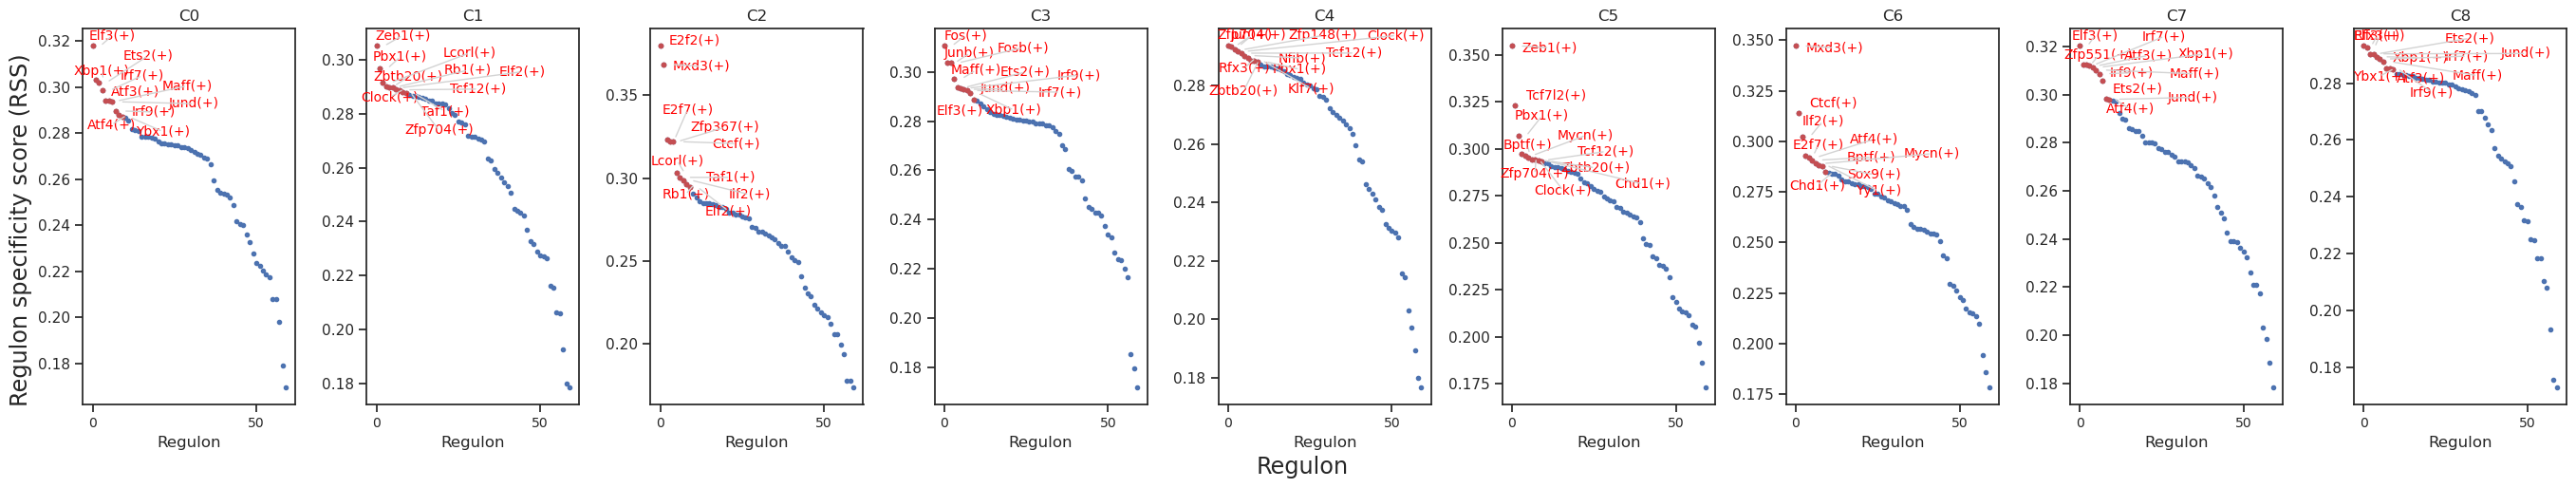

In [36]:
cats = sorted(list(set(cellAnnot['ClusterID'])))

fig = plt.figure(figsize=(len(cats)*3, 5)) # x*3,5
plt.rcParams['pdf.fonttype'] = 42
plt.gcf().set_size_inches(len(cats)*3, 5)
for c,num in zip(cats, range(1,len(cats)+1)):
    x=rss_cellType.T[c]
    ax = fig.add_subplot(1,len(cats),num)
    plot_rss(rss_cellType, c, top_n=10, max_n=None, ax=ax)
    ax.set_ylim( x.min()-(x.max()-x.min())*0.05 , x.max()+(x.max()-x.min())*0.05 )
    for t in ax.texts:
        t.set_fontsize(10)
    ax.set_ylabel('')
    ax.set_xticks(np.arange(0, len(x), 50))
    ax.set_xticklabels(np.arange(0, len(x), 50), fontsize=10)
    adjust_text(ax.texts, autoalign='xy', ha='right', va='bottom', arrowprops=dict(arrowstyle='-',color='lightgrey'), precision=0.001 )
 
fig.text(0.5, 0.0, 'Regulon', ha='center', va='center', size='x-large')
fig.text(0.00, 0.5, 'Regulon specificity score (RSS)', ha='center', va='center', rotation='vertical', size='x-large')
plt.tight_layout()
plt.rcParams.update({
    'figure.autolayout': True,
        'figure.titlesize': 'large' ,
        'axes.labelsize': 'medium',
        'axes.titlesize':'large',
        'xtick.labelsize':'medium',
        'ytick.labelsize':'medium'
        })
plt.savefig(INDIR+"sc_GRN2.pdf", dpi=600, bbox_inches = "tight")
plt.show()

In [11]:
cellAnnot.to_csv(INDIR+'result1.cellAnnot.csv')
auc_mtx.to_csv(INDIR+'result2.auc_mtx.csv')
rss_cellType.to_csv(INDIR+'result3.rss_cellType.csv')

In [28]:
rss_cellType

,Arnt(+),Arntl2(+),Atf1(+),Atf2(+),Atf3(+),Atf4(+),Atf7(+),Bach1(+),Bclaf1(+),Bptf(+),...,Zfp239(+),Zfp280d(+),Zfp281(+),Zfp354c(+),Zfp407(+),Zfp516(+),Zfp646(+),Zfp704(+),Zfx(+),Zscan26(+)
C0: Epithelial-like 1,0.313758,0.169520,0.275157,0.292134,0.384076,0.339754,0.294947,0.357855,0.305449,0.319205,...,NaN,0.281795,NaN,0.306252,0.300381,0.215620,0.197325,0.293454,0.298525,0.167445
C1: Neuronal-like 1,0.325414,0.167445,0.330297,0.340782,0.290521,0.330568,0.326481,0.312889,0.329671,0.333138,...,NaN,0.349014,NaN,0.336564,0.328853,0.328542,0.178808,0.337213,0.333386,0.167445
C2: Neuronal-like 2,0.290702,0.167445,0.425710,0.307868,0.280281,0.311504,0.286719,0.266902,0.287229,0.303082,...,NaN,0.353783,NaN,0.316888,0.303752,0.217885,0.170220,0.307448,0.293112,0.168186
C3: Epithelial-like 2,0.297755,0.168448,0.255702,0.288628,0.326854,0.302165,0.299803,0.333516,0.302763,0.297497,...,NaN,0.278118,NaN,0.297030,0.304805,0.302782,0.282589,0.275649,0.305433,0.218363
C4: Hybrid state 1,0.330897,0.172891,0.247747,0.315848,0.298876,0.285163,0.320058,0.294044,0.307496,0.299605,...,NaN,0.293376,NaN,0.316619,0.311742,0.213554,0.199494,0.329992,0.303483,0.168262
C5: Neuronal-like 3,0.289359,0.178734,0.275664,0.306645,0.243042,0.273415,0.297286,0.267865,0.318134,0.304898,...,NaN,0.293044,NaN,0.298006,0.288971,0.328334,0.187708,0.311501,0.306367,0.169353
C6: Hybrid state 2,0.215483,0.167445,0.266113,0.236143,0.229638,0.244456,0.214043,0.230453,0.237687,0.242999,...,NaN,0.226853,NaN,0.229468,0.218135,0.297916,0.170292,0.223574,0.243451,0.167445
C7: Epithelial-like 3,0.222853,0.167445,0.180680,0.207158,0.246461,0.235353,0.210192,0.237875,0.214862,0.220232,...,NaN,0.205077,NaN,0.214211,0.209005,0.203013,0.179249,0.210358,0.209786,0.167445
C8: Epithelial-like 4,0.205294,0.167445,0.196259,0.200669,0.208905,0.205557,0.201711,0.207787,0.201765,0.202504,...,NaN,0.200139,NaN,0.201189,0.200953,0.187014,0.184238,0.199736,0.200024,0.167445
